In [1]:
suppressMessages({
    library(dplyr)
    library(Matrix)
    library(data.table)
    library(Seurat)
    library(ggplot2)
    library(RColorBrewer)
    library(ggalluvial)
    library(readxl)
    library(dplyr)
    library(reshape2)
    library(ggsci)
    library(clusterProfiler)
    library("org.Hs.eg.db")
    library(tidyr)
    library(patchwork)
    library(cowplot)
    library(harmony)
    library(ggpubr)
    library(ComplexHeatmap)
    library(stringr)  
    set.seed(123)
    })

In [ ]:
cols<- unique(c("#FFFF00","#1CE6FF","#FF34FF","#FF4A46","#008941","#006FA6","#A30059","#FFE4E1","#0000A6","#B79762","#004D43","#8FB0FF","#997D87","#5A0007","#809693","#1B4400","#4FC601","#3B5DFF","#BA0900","#FF2F80","#6B7900","#00C2A0","#FFAA92","#FF90C9","#B903AA","#DDEFFF","#7B4F4B","#A1C299","#0AA6D8","#00A087FF","#4DBBD5FF","#E64B35FF","#3C5488FF","#0067A5","#63FFAC","#F38400","#A1CAF1", "#C2B280","#848482","#E68FAC", "#F99379", "#604E97","#F6A600", "#B3446C","#DCD300","#882D17", "#8DB600","#654522", "#E25822", "#2B3D26", "#191970","#000080","#6495ED","#1E90FF","#00BFFF","#00FFFF","#FF1493", "#FF00FF","#A020F0","#63B8FF","#008B8B","#54FF9F", "#00FF00","#76EE00","#FFF68F","Yellow1","Gold1", "DarkGoldenrod4","#FF6A6A","#FF8247","#FFA54F","#FF7F24", "#FF3030","#FFA500","#FF7F00","#FF7256","#FF6347", "#FF4500","#FF6EB4","#EE30A7","#8B008B","green",brewer.pal(9,"Set1")[-9],brewer.pal(12,"Paired")[c(3,4,6,8,10,12)],brewer.pal(8, "Dark2"),'#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b', '#e377c2', '#b5bd61', '#17becf' ,'#ffbb78','#ff9896')) ## unique 113

In [2]:
scRNA.sub = readRDS("EX_CA3-4.rds")

In [3]:
celltype = c('0','1','2','3','4')
best_color =c("#FFFF00","#1CE6FF","#FF4A46","#008941","#FF34FF")
names(best_color) = celltype

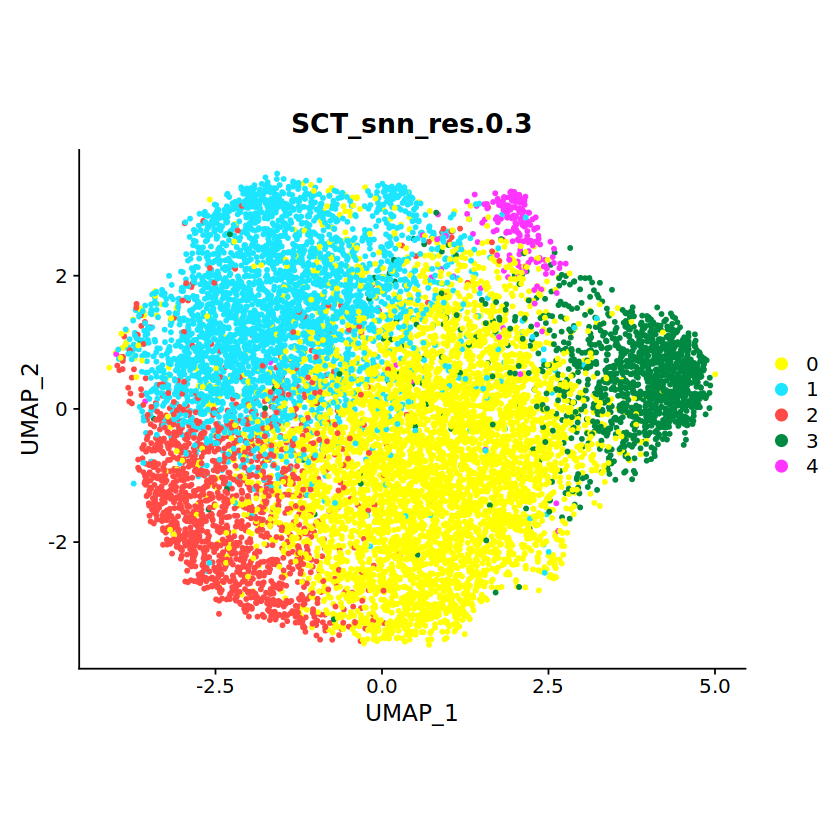

In [5]:
p = DimPlot(scRNA.sub, reduction = "umap",group.by="SCT_snn_res.0.3", label = FALSE, pt.size = 1,cols=best_color)+coord_fixed()  
p

In [38]:
obj = scRNA.sub

In [39]:
### all MT genes
mt.genes <- grep("^MT-", rownames(obj), value = TRUE)
length(mt.genes)
head(mt.genes)

[1] 36

[1] "MT-TF"   "MT-TV"   "MT-RNR1" "MT-TL1"  "MT-TI"   "MT-TQ"

In [41]:
DefaultAssay(obj) ="RNA"

In [42]:
### del MT gene
obj.noMT <- subset(obj, features = setdiff(rownames(obj), mt.genes))
grep("^MT-", rownames(obj.noMT), value = TRUE)

[1] "MT-TN"

In [43]:
obj.noMT = SCTransform(obj.noMT)
obj.noMT = NormalizeData(obj.noMT)   
obj.noMT = FindVariableFeatures(obj.noMT, selection.method = "vst")
obj.noMT = ScaleData(obj.noMT)
obj.noMT <- RunPCA(obj.noMT, features = VariableFeatures(obj.noMT))

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 25009 by 11383

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 5000 cells



  |======================================================================| 100%


Found 11 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 25009 genes



  |======================================================================| 100%


Computing corrected count matrix for 25009 genes



  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 4.682059 mins

Determine variable features

Place corrected count matrix in counts slot

Centering data matrix

Set default assay to SCT

Centering and scaling data matrix

PC_ 1 
Positive:  GFAP, CLU, AQP4, CD74, TMSB4X, C3, LAPTM5, PLP1, NDUFA4, ZFP36L1 
	   EFEMP1, GJA1, CSF1R, SELPLG, PTN, AQP1, STOM, BBOX1, PMP2, SPARCL1 
	   MBP, SLC1A3, ZFP36L2, AHNAK, PLPP3, CX3CR1, CDC42EP4, ID2, LRP4, CD44 
Negative:  MALAT1, CNTNAP2, CSMD1, NRG3, ROBO2, RBFOX1, KCNIP4, CADM2, NLGN1, ADGRB3 
	   PDE4D, DLG2, NRXN3, KCNQ5, EPHA6, NKAIN2, SNTG1, DMD, PCDH9, AC073050.1 
	   LRP1B, CNTN5, AL356534.1, MAGI2, MBD5, LRRC4C, HCN1, CARTPT, KCNQ1OT1, DANT2 
PC_ 2 
Positive:  GFAP, PLP1, SPARCL1, AQP4, MBP, CD74, GJA1, MTND1P23, DPP10, SLC1A3 
	   CLU, EFEMP1, AQP1, NEAT1, IL1RAPL1, ETNPPL, RAD51B, LAPTM5, CSF1R, AHCYL1 
	   AHNAK, ZFP36L1, ITPKB, C3, PDYN, ZFP36L2, ADD3, PLPP3, LDLRAD4, RPS4Y1 
Negative:  NDUFA4, CCK, TMSB4X, CARTPT, SN

ERROR: Error in data.use %*% cell.embeddings: non-conformable arguments


In [47]:
obj.noMT[["harmony"]] <- NULL
obj.noMT = RunHarmony(obj.noMT,group.by.vars="sample", max.iter.harmony = 20, project.dim = FALSE) %>% 
                FindNeighbors(reduction = "harmony", dims = 1:20)%>% 
                FindClusters(resolution =c(0.5))
obj.noMT = RunUMAP(obj.noMT, reduction = "harmony", dims = 1:20) 

Harmony 1/20

Harmony 2/20

Harmony 3/20

Harmony 4/20

Harmony 5/20

Harmony 6/20

Harmony 7/20

Harmony 8/20

Harmony 9/20

Harmony 10/20

Harmony 11/20

Harmony 12/20

Harmony 13/20

Harmony 14/20

Harmony converged after 14 iterations

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 11383
Number of edges: 267606

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7331
Number of communities: 5
Elapsed time: 1 seconds


18:44:21 UMAP embedding parameters a = 0.9922 b = 1.112

18:44:21 Read 11383 rows and found 20 numeric columns

18:44:21 Using Annoy for neighbor search, n_neighbors = 30

18:44:21 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:44:21 Writing NN index file to temp file /tmp/Rtmpy3KG0Q/filed038628237

18:44:21 Searching Annoy index using 1 thread, search_k = 3000

18:44:25 Annoy recall = 100%

18:44:26 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

18:44:27 Initializing from normalized Laplacian + noise (using irlba)

18:44:28 Commencing optimization for 200 epochs, with 446368 positive edges

18:44:40 Optimization finished



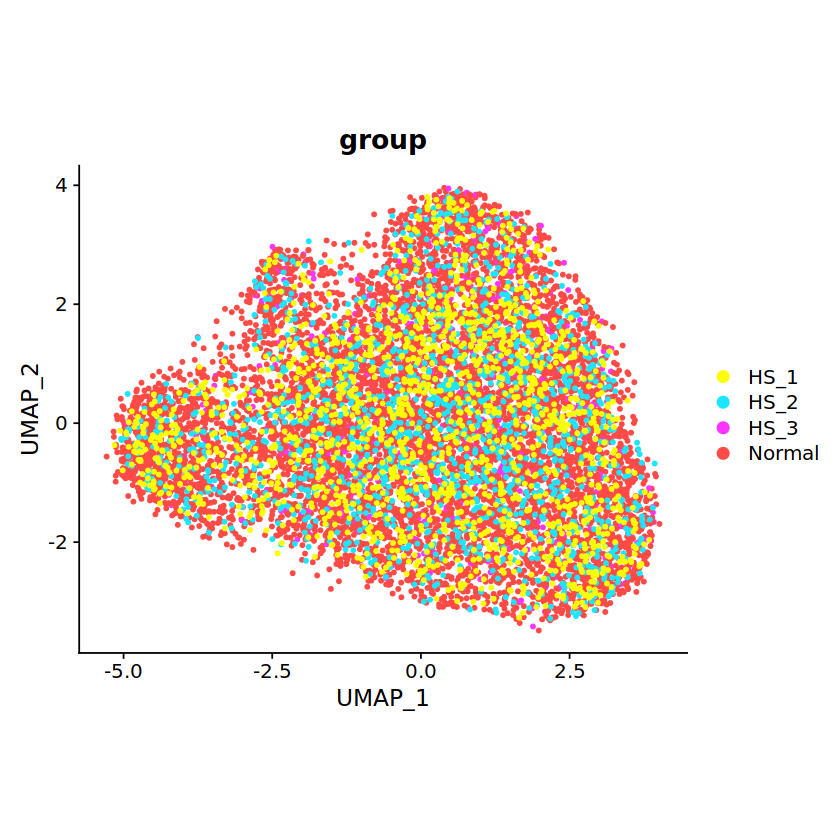

In [50]:
p = DimPlot(obj.noMT, reduction = "umap",group.by="group", label = FALSE, pt.size = 1,cols=cols)+coord_fixed() 
p

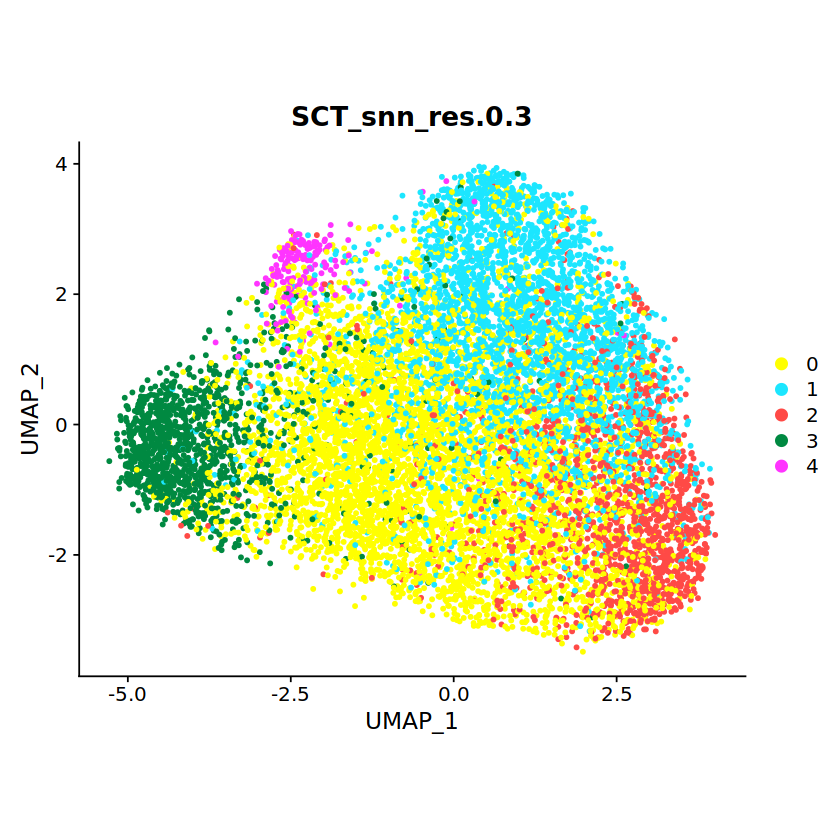

In [49]:
p = DimPlot(obj.noMT, reduction = "umap",group.by="SCT_snn_res.0.3", label = FALSE, pt.size = 1,cols=best_color)+coord_fixed()  
p

In [51]:
saveRDS(obj.noMT,"recluster.rds")